# 제2장 데이터 요약과 시각화 (4)
### __데이터 시각화__


---
### 사전 작업





* 실습에 사용할 데이터를 GitHub 저장소로부터 가져오기 위하여 다음과 같은 명령을 코랩 코드 셀에서 실행

In [1]:
!git clone https://github.com/BizStat/BizDataAnalysis.git

Cloning into 'BizDataAnalysis'...
remote: Enumerating objects: 222, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 222 (delta 16), reused 40 (delta 8), pack-reused 174 (from 1)
Receiving objects: 100% (222/222), 124.71 MiB | 10.43 MiB/s, done.
Resolving deltas: 100% (69/69), done.
Updating files: 100% (40/40), done.


* 한글 폰트 설치와 matplotlib 환경 설정

In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -f -v
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,598 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126210 files and dire

* 한글 그래프 환경 적용을 위해 세션 다시 시작
  - 위의 메뉴에서 [런타임] -> [세션 다시 시작] 을 선택하거나 [Control] + M 을 누르면 됨

* matplotlib에 사용할 한글 폰트 설정
  - 앞의 한글 폰트 목록으로부터 자신이 사용하고자 하는 폰트이름을 복사하여 지정

In [1]:
from matplotlib import rc
rc('font', family='NanumMyeongjo')
rc('axes', unicode_minus=False)

* 자주 사용하는 라이브러리 가져오기

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

___

(1) 상자도표 그리기

* 서울시 대기오염 데이터에서 각 측정소의 미세먼지 분포를 상자도표를 이용해 살펴보기

In [ ]:
seoul_air = pd.read_csv('/content/BizDataAnalysis/DATA/AIR_HOUR_2022.csv')

In [ ]:
seoul_air.columns

In [ ]:
seoul_air = seoul_air[seoul_air['측정기 상태'] == 0]

<Axes: >

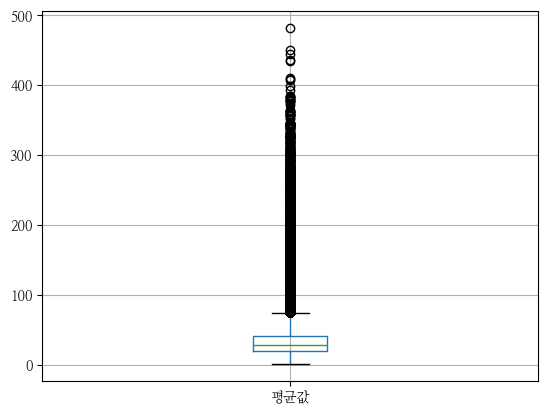

In [ ]:
seoul_air[seoul_air['측정항목'] == 8].boxplot(column='평균값')

<Axes: >

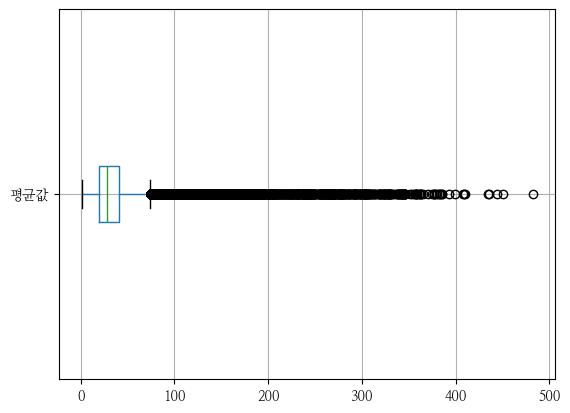

In [ ]:
seoul_air[seoul_air['측정항목'] == 8].boxplot(column='평균값',vert=False)

<Axes: >

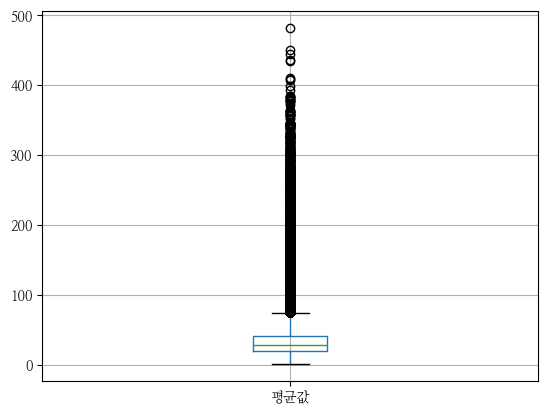

In [ ]:
seoul_air[seoul_air['측정항목'] == 8][['평균값']].boxplot()

<Axes: title={'center': '평균값'}, xlabel='측정소 코드'>

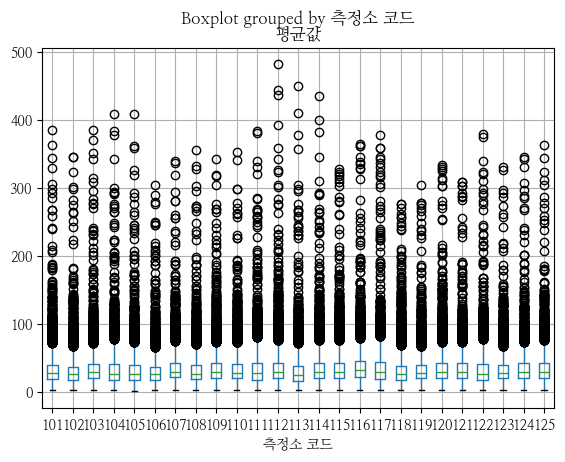

In [ ]:
seoul_air[seoul_air['측정항목'] == 8].boxplot(column='평균값',by='측정소 코드')

,0
101,"Axes(0.1,0.77069;0.137931x0.12931)"
102,"Axes(0.265517,0.77069;0.137931x0.12931)"
103,"Axes(0.431034,0.77069;0.137931x0.12931)"
104,"Axes(0.596552,0.77069;0.137931x0.12931)"
105,"Axes(0.762069,0.77069;0.137931x0.12931)"
106,"Axes(0.1,0.615517;0.137931x0.12931)"
107,"Axes(0.265517,0.615517;0.137931x0.12931)"
108,"Axes(0.431034,0.615517;0.137931x0.12931)"
109,"Axes(0.596552,0.615517;0.137931x0.12931)"
110,"Axes(0.762069,0.615517;0.137931x0.12931)"


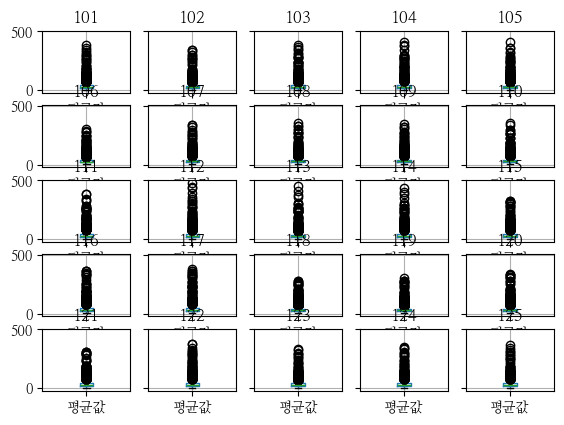

In [ ]:
seoul_air[seoul_air['측정항목'] == 8].groupby('측정소 코드')[['평균값']].boxplot()

(2) 히스토그램 그리기

* 서울시 대기오염 데이터에서 미세먼지 측정값의 분포를 히스토그램 그리기

`

array([[<Axes: title={'center': '평균값'}>]], dtype=object)

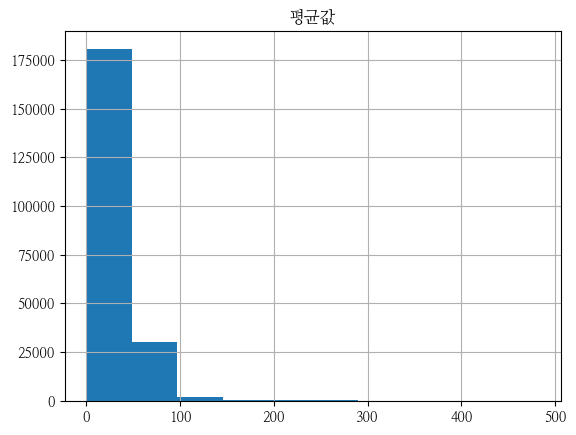

In [ ]:
seoul_air[seoul_air['측정항목'] == 8].hist(column='평균값')

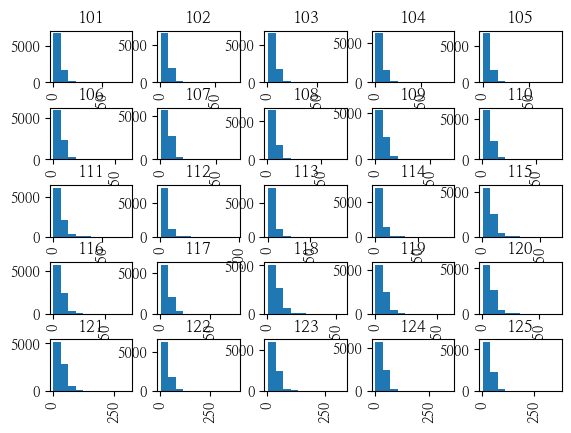

In [ ]:
seoul_air[seoul_air['측정항목'] == 8].hist(column='평균값',by='측정소 코드')
plt.show()

(array([1.8084e+05, 3.0317e+04, 2.1700e+03, 3.6300e+02, 1.5500e+02,
        1.4500e+02, 9.1000e+01, 4.5000e+01, 5.0000e+00, 5.0000e+00]),
 array([  1. ,  49.1,  97.2, 145.3, 193.4, 241.5, 289.6, 337.7, 385.8,
        433.9, 482. ]),
 <BarContainer object of 10 artists>)

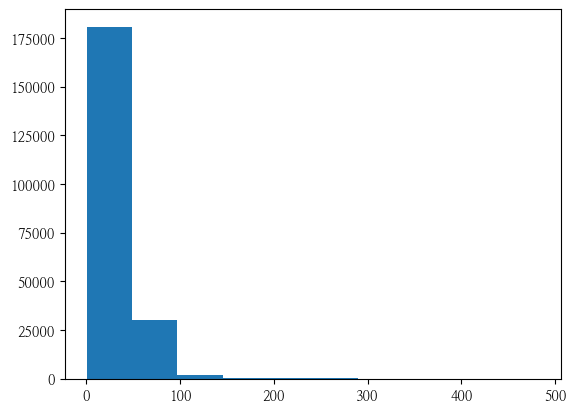

In [ ]:
plt.hist(seoul_air[seoul_air['측정항목'] == 8]['평균값'])

* 히스토그램 작성에 사용된 값 가져오기

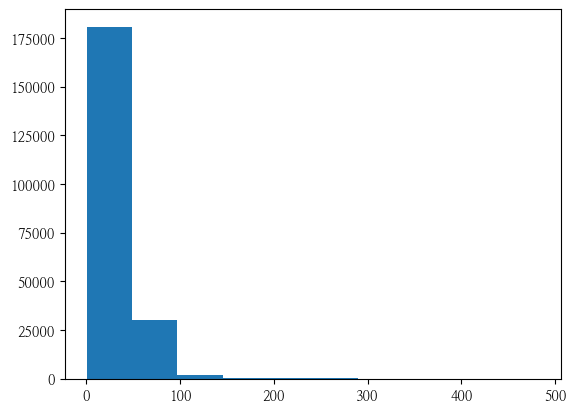

In [ ]:
hist, bins, _ = plt.hist(seoul_air[seoul_air['측정항목'] == 8]['평균값'])

In [ ]:
bins

array([  1. ,  49.1,  97.2, 145.3, 193.4, 241.5, 289.6, 337.7, 385.8,
       433.9, 482. ])

In [ ]:
hist

array([1.8084e+05, 3.0317e+04, 2.1700e+03, 3.6300e+02, 1.5500e+02,
       1.4500e+02, 9.1000e+01, 4.5000e+01, 5.0000e+00, 5.0000e+00])

In [ ]:
for i in range(len(hist)):
    print(f"구간 {i+1}: {bins[i]} <= x < {bins[i+1]} - 빈도수: {hist[i]}")

구간 1: 1.0 <= x < 49.1 - 빈도수: 180840.0
구간 2: 49.1 <= x < 97.2 - 빈도수: 30317.0
구간 3: 97.2 <= x < 145.3 - 빈도수: 2170.0
구간 4: 145.3 <= x < 193.4 - 빈도수: 363.0
구간 5: 193.4 <= x < 241.5 - 빈도수: 155.0
구간 6: 241.5 <= x < 289.6 - 빈도수: 145.0
구간 7: 289.6 <= x < 337.7 - 빈도수: 91.0
구간 8: 337.7 <= x < 385.8 - 빈도수: 45.0
구간 9: 385.8 <= x < 433.90000000000003 - 빈도수: 5.0
구간 10: 433.90000000000003 <= x < 482.0 - 빈도수: 5.0


(3) 산점도

* Advertiser.xlsx 파일 가져와 ad_df라는 이름의 데이터프레임 만들기

In [ ]:
ad_df = pd.read_excel('/content/BizDataAnalysis/DATA/Advertiser.xlsx')

In [ ]:
ad_df.plot('TV','Radio',kind='scatter')

In [ ]:
plt.scatter(ad_df['TV'],ad_df['Radio'])

In [ ]:
sns.scatterplot(x=ad_df['TV'],y=ad_df['Radio'])

In [ ]:
sns.scatterplot(data=ad_df,x='TV',y='Radio')

* seaborn 라이브러리의 pairplot을 이용해 여러 변수들의 산점도 한 번에 표현

In [ ]:
sns.pairplot(data = ad_df,vars = ["TV", "Radio", "Magazine",'Newspaper'])

In [ ]:
sns.pairplot(data = ad_df,vars = ["TV", "Radio", "Magazine",'Newspaper'],corner=True)

(4) 막대 그래프와 파이 그래프

* 데이터 전처리

In [ ]:
seoul_air = pd.read_csv('/content/BizDataAnalysis/DATA/AIR_HOUR_2022.csv')
측정소정보 = pd.read_csv('/content/BizDataAnalysis/DATA/서울시 대기오염 측정소 정보.csv',encoding='EUC-KR')
측정항목정보 = pd.read_csv('/content/BizDataAnalysis/DATA/서울시 대기오염 측정항목 정보.csv',encoding='EUC-KR')
seoul_air = pd.merge(seoul_air,측정소정보,how='left',on='측정소 코드')
seoul_air = pd.merge(seoul_air,측정항목정보,how='left',left_on='측정항목', right_on='측정항목 코드')
sa1 = seoul_air[(seoul_air['측정소 이름'] == '서대문구') & (seoul_air['측정기 상태'] == 0)]
sa1 = sa1[['측정일시','측정항목 명(줄임 명칭)','평균값','국가 기준초과 구분']]
sa1.head()

  * 측정항목별 국가 기준초과 횟수를 파이 그래프로 표현

In [ ]:
tmp1 = sa1.groupby('국가 기준초과 구분')[['평균값']].count()
plt.pie(tmp1['평균값'], labels=tmp1.index, autopct='%.1f%%')

In [ ]:
tmp2 = sa1.groupby('측정항목 명(줄임 명칭)')[['평균값']].mean()
plt.bar(tmp2.index,tmp2['평균값'])

In [ ]:
plt.bar(tmp2.index,tmp2['평균값'])
plt.title("막대 그래프 그리기")
plt.xlabel('측정항목')
plt.ylabel('빈도')
plt.axhline(sa1['평균값'].mean(),color='grey',linestyle='--')
plt.show()